# import package

In [1]:
import numpy as np
import pandas as pd
import patsy.version
import doubleml as dml
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import math
import patsy 
from causalml.dataset.regression import *
from causalml.metrics import *
import scipy
import random
import tensorflow as tf
import torch

import optuna
from optuna.visualization import plot_optimization_history
import optuna.trial as trial

import contextlib
import io

Failed to import duecredit due to No module named 'duecredit'


# SNet_yc

SNet_yc loss

In [2]:
from tensorflow.keras import Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K

from causalml.inference.tf.utils import (
    dragonnet_loss_binarycross,
    EpsilonLayer,
    regression_loss,
    binary_classification_loss,
    treatment_accuracy,
    track_epsilon
)
from causalml.inference.meta.utils import convert_pd_to_np

def binary_useregression_loss(concat_true, concat_pred):
    t_true = concat_true[:, 1]
    t_pred = concat_pred[:, 2]
    t_pred = (t_pred + 0.001) / 1.002
    losst = tf.reduce_sum(tf.square(t_true - t_pred))

    return losst

def dragonnet_loss_binarycross_yc(concat_true, concat_pred):
    return regression_loss(concat_true, concat_pred) + binary_useregression_loss(
        concat_true, concat_pred
    )

def y_binary_classification_loss(concat_true, concat_pred):
    """
    Classification loss on y - used for MNIST causal effect
    """

    y_true = concat_true[:, 0]
    t_true = concat_true[:, 1]

    y0_pred = concat_pred[:, 0]
    y1_pred = concat_pred[:, 1]

    # y0_pred = tf.dtypes.cast(y0_pred, tf.int64)
    # y1_pred = tf.dtypes.cast(y1_pred, tf.int64)

    y_pred = t_true * y1_pred + (1 - t_true) * y0_pred

    # y_pred = tf.dtypes.cast(y_pred, tf.int64)
    try:
        y_pred = (y_pred.numpy() + 0.001) / 1.002
        y_true = y_true.numpy()
        y_true = y_true.astype('float32')
        y_pred = y_pred.astype('float32')
        y_loss = np.sum(K.binary_crossentropy(y_true, y_pred))
    except AttributeError:
        y_pred = (y_pred + 0.001) / 1.002
        # y_true = y_true.numpy()
        # y_true = y_true.astype('float32')
        # y_pred = y_pred.astype('float32')
        y_loss = tf.reduce_sum(K.binary_crossentropy(y_true, y_pred))
    return y_loss


def dragonnet_double_binarycross(concat_true, concat_pred):
    """
    Total Classification loss - used for MNIST causal effect
    """
    return y_binary_classification_loss(concat_true, concat_pred) + binary_classification_loss(concat_true, concat_pred)


def mu_risk_loss(concat_true, concat_pred):
    t_true = concat_true[:, 1]
    t_pred = concat_true[:, 2]

    y_true = concat_true[:, 0]
    y0_pred = concat_pred[:, 0]
    y1_pred = concat_pred[:, 1]
    y_pred = t_true * y1_pred + (1 - t_true) * y0_pred
    weight = t_true / t_pred + (1 - t_true) / (1 - t_pred)

    loss = tf.reduce_sum(tf.square(y_true - y_pred) * weight)
    return loss

def dragonnet_mu_risk(concat_true, concat_pred, alpha=1.0):
    return mu_risk_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)


def mu_risk_loss_ybinary(concat_true, concat_pred):
    t_true = concat_true[:, 1]
    t_pred = concat_true[:, 2]

    y_true = concat_true[:, 0]
    y0_pred = concat_pred[:, 0]
    y1_pred = concat_pred[:, 1]
    y_pred = t_true * y1_pred + (1 - t_true) * y0_pred
    y_pred = (y_pred + 0.001) / 1.002
    weight = t_true / t_pred + (1 - t_true) / (1 - t_pred)

    loss = tf.reduce_sum((K.binary_crossentropy(y_true, y_pred)) * weight)
    return loss

def dragonnet_mu_risk_ybinary(concat_true, concat_pred, alpha=1.0):
    return mu_risk_loss_ybinary(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)


class SNet_yc:
    def __init__(
        self,
        neurons_r_layer_w=50,
        neurons_r_layer_c0=50,
        # neurons_r_layer_c1=50,
        neurons_r_layer_o0=50,
        neurons_r_layer_o1=50,
        neurons_out_layer=64,
        num_layers=3,
        ratio=1.0,
        ratio2=1.0,
        val_split=0.3,
        batch_size=64,
        epochs=100,
        learning_rate=1e-5,
        momentum=0.9,
        reg_l2=0.01,
        reg_disc=False,
        reg_orth=False,
        use_adam=True,
        adam_epochs=30,
        adam_learning_rate=1e-3,
        loss_func=dragonnet_mu_risk,
        verbose=True,
    ):
        """
        Initializes a Dragonnet.
        """
        self.neurons_r_layer_w = neurons_r_layer_w
        self.neurons_r_layer_c0 = neurons_r_layer_c0
        # self.neurons_r_layer_c1 = neurons_r_layer_c1
        self.neurons_r_layer_o0 = neurons_r_layer_o0
        self.neurons_r_layer_o1 = neurons_r_layer_o1
        self.neurons_out_layer = neurons_out_layer
        self.num_layers = num_layers
        self.reg_disc = reg_disc
        self.ratio = ratio
        self.ratio2 = ratio2
        self.val_split = val_split
        self.batch_size = batch_size
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.use_adam = use_adam
        self.adam_learning_rate = adam_learning_rate
        self.adam_epochs = adam_epochs
        self.reg_l2 = reg_l2
        self.reg_orth = reg_orth
        self.loss_func = loss_func
        self.verbose = verbose

    def make_dragonnet(self, input_dim):
        """
        Neural net predictive model. The dragon has three heads.

        Args:
            input_dim (int): number of rows in input
        Returns:
            model (keras.models.Model): DragonNet model
        """
        inputs = Input(shape=(input_dim,), name="input")
        neurons_out_layer = self.neurons_out_layer

        # representation
        # instruments
        x_w = inputs
        for i in range(self.num_layers):
            nm=f"x_w_{i}"
            if i==0 :
                nm="input_instrument"
            x_w = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_w)
        
        nm = f"x_w_{self.num_layers}"
        if self.num_layers==0 :
            nm="input_instrument"
        x_w = Dense(
            name=nm,
            units=int(self.neurons_r_layer_w),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_w)
        hide_x_w=x_w

        # confounders
        x_c0 = inputs
        for i in range(self.num_layers):
            nm=f"x_c0_{i}"
            if i==0 :
                nm="input_confounder0"
            x_c0 = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_c0)
        
        nm = f"x_c0_{self.num_layers}"
        if self.num_layers==0 :
            nm="input_confounder0"
        x_c0 = Dense(
            name=nm,
            units=int(self.neurons_r_layer_c0),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_c0)
        hide_x_c0=x_c0

        # x_c1 = inputs
        # for i in range(self.num_layers):
        #     nm=f"x_c1_{i}"
        #     if i==0 :
        #         nm="input_confounder1"
        #     x_c1 = Dense(
        #         name=nm,
        #         units=int(neurons_out_layer),
        #         activation="elu",
        #         kernel_initializer="RandomNormal",
        #     )(x_c1)
        
        # nm = f"x_c1_{self.num_layers}"
        # if self.num_layers==0 :
        #     nm="input_confounder1"
        # x_c1 = Dense(
        #     name=nm,
        #     units=int(self.neurons_r_layer_c1),
        #     activation="linear",
        #     kernel_initializer="RandomNormal",
        # )(x_c1)
        # hide_x_c1=x_c1

        # outcomes
        x_o0 = inputs
        for i in range(self.num_layers):
            nm=f"x_o0_{i}"
            if i==0 :
                nm="input_adjustment0"
            x_o0 = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_o0)
        
        nm = f"x_o0_{self.num_layers}"
        if self.num_layers==0 :
            nm="input_adjustment0"
        x_o0 = Dense(
            name=nm,
            units=int(self.neurons_r_layer_o0),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_o0)
        hide_x_o0=x_o0

        x_o1 = inputs
        for i in range(self.num_layers):
            nm=f"x_o1_{i}"
            if i==0 :
                nm="input_adjustment1"
            x_o1 = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_o1)
        
        nm = f"x_o1_{self.num_layers}"
        if self.num_layers==0 :
            nm="input_adjustment1"
        x_o1 = Dense(
            name=nm,
            units=int(self.neurons_r_layer_o1),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_o1)
        hide_x_o1=x_o1

        
        # x_wc = Concatenate(1)([x_w,x_c0,x_c1])
        x_wc = Concatenate(1)([x_w,x_c0])
        t_predictions = Dense(units=1, activation="sigmoid",name="t_predictions",)(x_wc)


        # HYPOTHESIS
        x_co0 = Concatenate(1)([x_c0,x_o0])
        # x_co1 = Concatenate(1)([x_c0,x_o0,x_c1,x_o1])
        x_co1 = Concatenate(1)([x_c0,x_o0,x_o1])
        y0_hidden = x_co0
        y1_hidden = x_co1
        for i in range(self.num_layers):
            y0_hidden = Dense(
                name=f"y0_hidden_{i+1}",
                units=int(neurons_out_layer),
                activation="elu",
                kernel_regularizer=l2(self.reg_l2),
            )(y0_hidden)

            y1_hidden = Dense(
                name=f"y1_hidden_{i+1}",
                units=int(neurons_out_layer),
                activation="elu",
                kernel_regularizer=l2(self.reg_l2),
            )(y1_hidden)

        # prediction
        y0_predictions = Dense(
            units=1,
            activation="linear",
            kernel_regularizer=l2(self.reg_l2),
            name="y0_predictions",
        )(y0_hidden)
        y1_predictions = Dense(
            units=1,
            activation="linear",
            kernel_regularizer=l2(self.reg_l2),
            name="y1_predictions",
        )(y1_hidden)

        dl = EpsilonLayer()
        epsilons = dl(t_predictions, name="epsilon")
        concat_pred = Concatenate(1)(
            # [y0_predictions, y1_predictions, t_predictions, epsilons, hide_x_w, hide_x_c0, hide_x_c1, hide_x_o0, hide_x_o1]
            [y0_predictions, y1_predictions, t_predictions, epsilons, hide_x_w, hide_x_c0, hide_x_o0, hide_x_o1]
        )
        model = Model(inputs=inputs, outputs=concat_pred)

        return model
    

    def fit(self, X, treatment, y, nuis_e=None, p=None):
        """
        Fits the DragonNet model.

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
            treatment (np.array or pd.Series): a treatment vector
            y (np.array or pd.Series): an outcome vector
        """
        if nuis_e is None:
            X, treatment, y = convert_pd_to_np(X, treatment, y)
            y = np.hstack((y.reshape(-1, 1), treatment.reshape(-1, 1)))
        else :
            X, treatment, y, nuis_e = convert_pd_to_np(X, treatment, y, nuis_e)
            y = np.hstack((y.reshape(-1, 1), treatment.reshape(-1, 1), nuis_e.reshape(-1, 1)))

        self.dragonnet = self.make_dragonnet(X.shape[1])

        metrics = [
            mu_risk_loss,
            binary_classification_loss,
            treatment_accuracy,
            track_epsilon,
        ]

        layers=self.dragonnet.layers
        layers_names=[]
        for i in range(len(layers)):
            a_layer=self.dragonnet.layers[i]
            layers_names=layers_names+[a_layer.name]
        layers_names=np.array(layers_names)
        layers_names_idx=list(range(len(layers)))
        layers_names_idx=np.array(layers_names_idx)

        def MMD2(concat_true, concat_pred):
            t_true = concat_true[:, 1]
            # Zy = concat_pred[:, (4+self.neurons_r_layer_w + self.neurons_r_layer_c0 + self.neurons_r_layer_c1):tf.shape(concat_pred)[1]]
            # Zy = concat_pred[:, (4+self.neurons_r_layer_w + self.neurons_r_layer_c0):tf.shape(concat_pred)[1]]
            Zy = concat_pred[:, (4+self.neurons_r_layer_w + self.neurons_r_layer_c0):(4+self.neurons_r_layer_w + self.neurons_r_layer_c0 + self.neurons_r_layer_o0)]
            Zy0 = Zy[t_true==0]
            Zy1 = Zy[t_true==1]
            n = tf.shape(Zy0)[0]
            m = tf.shape(Zy1)[0]

            def gaussian_kernel(x, y, sigma=1.0):
                dist_sq = tf.square(tf.norm(tf.expand_dims(x, 1) - tf.expand_dims(y, 0), axis=2))
                return tf.exp(-dist_sq / (2.0 * sigma ** 2))
            
            Kxx = gaussian_kernel(Zy0, Zy0)
            Kyy = gaussian_kernel(Zy1, Zy1)
            Kxy = gaussian_kernel(Zy0, Zy1)
            sum_Kxx = (tf.reduce_sum(Kxx) - tf.reduce_sum(tf.linalg.diag_part(Kxx))) / (tf.cast(n, tf.float32) * (tf.cast(n, tf.float32) - 1))
            sum_Kyy = (tf.reduce_sum(Kyy) - tf.reduce_sum(tf.linalg.diag_part(Kyy))) / (tf.cast(m, tf.float32) * (tf.cast(m, tf.float32) - 1))
            # sum_Kxx = (tf.reduce_sum(Kxx)) / (tf.cast(n, tf.float32) * (tf.cast(n, tf.float32)))
            # sum_Kyy = (tf.reduce_sum(Kyy)) / (tf.cast(m, tf.float32) * (tf.cast(m, tf.float32)))
            sum_Kxy = tf.reduce_sum(Kxy) / (tf.cast(n, tf.float32) * tf.cast(m, tf.float32))
            mmd = sum_Kxx + sum_Kyy - 2 * sum_Kxy
            sample_size = tf.shape(concat_pred)[0]
            sample_size = tf.cast(sample_size, tf.float32)

            return mmd*sample_size

        if self.reg_disc:
            def loss_MMD2(concat_true, concat_pred):
                # tf.print(MMD2(concat_true, concat_pred))
                return self.loss_func(concat_true, concat_pred) + self.ratio * MMD2(concat_true, concat_pred)
            loss = loss_MMD2
            if self.reg_orth:
                def loss_MMD2_orth(concat_true, concat_pred):
                    layer_w0=self.dragonnet.layers[layers_names_idx[layers_names=="input_instrument"][0]]
                    weights_w0,bias_w0 = layer_w0.weights
                    layer_c00=self.dragonnet.layers[layers_names_idx[layers_names=="input_confounder0"][0]]
                    weights_c00,bias_c00 = layer_c00.weights
                    # layer_c01=self.dragonnet.layers[layers_names_idx[layers_names=="input_confounder1"][0]]
                    # weights_c01,bias_c01 = layer_c01.weights
                    layer_o00=self.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment0"][0]]
                    weights_o00,bias_o00 = layer_o00.weights
                    layer_o01=self.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment1"][0]]
                    weights_o01,bias_o01 = layer_o01.weights
                    instrument_wts=tf.reduce_sum(tf.abs(weights_w0),axis=1)
                    instrument_wts=instrument_wts/tf.sqrt(tf.reduce_sum(instrument_wts**2))
                    confounder_wts0=tf.reduce_sum(tf.abs(weights_c00),axis=1)
                    confounder_wts0=confounder_wts0/tf.sqrt(tf.reduce_sum(confounder_wts0**2))
                    # confounder_wts1=tf.reduce_sum(tf.abs(weights_c01),axis=1)
                    # confounder_wts1=confounder_wts1/tf.sqrt(tf.reduce_sum(confounder_wts1**2))
                    adjustment_wts0=tf.reduce_sum(tf.abs(weights_o00),axis=1)
                    adjustment_wts0=adjustment_wts0/tf.sqrt(tf.reduce_sum(adjustment_wts0**2))
                    adjustment_wts1=tf.reduce_sum(tf.abs(weights_o01),axis=1)
                    adjustment_wts1=adjustment_wts1/tf.sqrt(tf.reduce_sum(adjustment_wts1**2))
                    # return self.loss_func(concat_true, concat_pred) + self.ratio * MMD2(concat_true, concat_pred) + \
                    #     self.ratio2 * (tf.reduce_sum(instrument_wts*confounder_wts0)+tf.reduce_sum(instrument_wts*confounder_wts1)+\
                    #                    tf.reduce_sum(instrument_wts*adjustment_wts0)+tf.reduce_sum(instrument_wts*adjustment_wts1)+\
                    #                    tf.reduce_sum(confounder_wts0*confounder_wts1)+tf.reduce_sum(confounder_wts0*adjustment_wts0)+tf.reduce_sum(confounder_wts0*adjustment_wts1)+\
                    #                    tf.reduce_sum(confounder_wts1*adjustment_wts0)+tf.reduce_sum(confounder_wts1*adjustment_wts1)+\
                    #                    tf.reduce_sum(adjustment_wts0*adjustment_wts1))
                    return self.loss_func(concat_true, concat_pred) + self.ratio * MMD2(concat_true, concat_pred) + \
                        self.ratio2 * (tf.reduce_sum(instrument_wts*confounder_wts0)+\
                                       tf.reduce_sum(instrument_wts*adjustment_wts0)+tf.reduce_sum(instrument_wts*adjustment_wts1)+\
                                       tf.reduce_sum(confounder_wts0*adjustment_wts0)+tf.reduce_sum(confounder_wts0*adjustment_wts1)+\
                                       tf.reduce_sum(adjustment_wts0*adjustment_wts1))
                loss = loss_MMD2_orth
        else:
            loss = self.loss_func
            if self.reg_orth:
                def loss_orth(concat_true, concat_pred):
                    layer_w0=self.dragonnet.layers[layers_names_idx[layers_names=="input_instrument"][0]]
                    weights_w0,bias_w0 = layer_w0.weights
                    layer_c00=self.dragonnet.layers[layers_names_idx[layers_names=="input_confounder0"][0]]
                    weights_c00,bias_c00 = layer_c00.weights
                    # layer_c01=self.dragonnet.layers[layers_names_idx[layers_names=="input_confounder1"][0]]
                    # weights_c01,bias_c01 = layer_c01.weights
                    layer_o00=self.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment0"][0]]
                    weights_o00,bias_o00 = layer_o00.weights
                    layer_o01=self.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment1"][0]]
                    weights_o01,bias_o01 = layer_o01.weights
                    instrument_wts=tf.reduce_sum(tf.abs(weights_w0),axis=1)
                    instrument_wts=instrument_wts/tf.sqrt(tf.reduce_sum(instrument_wts**2))
                    confounder_wts0=tf.reduce_sum(tf.abs(weights_c00),axis=1)
                    confounder_wts0=confounder_wts0/tf.sqrt(tf.reduce_sum(confounder_wts0**2))
                    # confounder_wts1=tf.reduce_sum(tf.abs(weights_c01),axis=1)
                    # confounder_wts1=confounder_wts1/tf.sqrt(tf.reduce_sum(confounder_wts1**2))
                    adjustment_wts0=tf.reduce_sum(tf.abs(weights_o00),axis=1)
                    adjustment_wts0=adjustment_wts0/tf.sqrt(tf.reduce_sum(adjustment_wts0**2))
                    adjustment_wts1=tf.reduce_sum(tf.abs(weights_o01),axis=1)
                    adjustment_wts1=adjustment_wts1/tf.sqrt(tf.reduce_sum(adjustment_wts1**2))
                    # return self.loss_func(concat_true, concat_pred) + \
                    #     self.ratio2 * (tf.reduce_sum(instrument_wts*confounder_wts0)+tf.reduce_sum(instrument_wts*confounder_wts1)+\
                    #                    tf.reduce_sum(instrument_wts*adjustment_wts0)+tf.reduce_sum(instrument_wts*adjustment_wts1)+\
                    #                    tf.reduce_sum(confounder_wts0*confounder_wts1)+tf.reduce_sum(confounder_wts0*adjustment_wts0)+tf.reduce_sum(confounder_wts0*adjustment_wts1)+\
                    #                    tf.reduce_sum(confounder_wts1*adjustment_wts0)+tf.reduce_sum(confounder_wts1*adjustment_wts1)+\
                    #                    tf.reduce_sum(adjustment_wts0*adjustment_wts1))
                    return self.loss_func(concat_true, concat_pred) + self.ratio * MMD2(concat_true, concat_pred) + \
                        self.ratio2 * (tf.reduce_sum(instrument_wts*confounder_wts0)+\
                                       tf.reduce_sum(instrument_wts*adjustment_wts0)+tf.reduce_sum(instrument_wts*adjustment_wts1)+\
                                       tf.reduce_sum(confounder_wts0*adjustment_wts0)+tf.reduce_sum(confounder_wts0*adjustment_wts1)+\
                                       tf.reduce_sum(adjustment_wts0*adjustment_wts1))
                loss = loss_orth


        if self.use_adam:
            self.dragonnet.compile(
                optimizer=Adam(learning_rate=self.adam_learning_rate),
                loss=loss,
                metrics=metrics,
            )

            adam_callbacks = [
                TerminateOnNaN(),
                EarlyStopping(monitor="val_loss", patience=40, min_delta=0.0),
                ReduceLROnPlateau(
                    monitor="loss",
                    factor=0.5,
                    patience=5,
                    verbose=self.verbose,
                    mode="auto",
                    min_delta=1e-8,
                    cooldown=0,
                    min_lr=0,
                ),
            ]

            self.dragonnet.fit(
                X,
                y,
                callbacks=adam_callbacks,
                validation_split=self.val_split,
                epochs=self.adam_epochs,
                batch_size=self.batch_size,
                verbose=self.verbose,
            )

        sgd_callbacks = [
            TerminateOnNaN(),
            EarlyStopping(monitor="val_loss", patience=40, min_delta=0.0),
            ReduceLROnPlateau(
                monitor="loss",
                factor=0.5,
                patience=5,
                verbose=self.verbose,
                mode="auto",
                min_delta=0.0,
                cooldown=0,
                min_lr=0,
            ),
        ]

        self.dragonnet.compile(
            optimizer=SGD(
                learning_rate=self.learning_rate, momentum=self.momentum, nesterov=True
            ),
            loss=loss,
            metrics=metrics,
        )
        self.dragonnet.fit(
            X,
            y,
            callbacks=sgd_callbacks,
            validation_split=self.val_split,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
        )

    def predict(self, X, treatment=None, y=None, p=None):
        """
        Calls predict on fitted DragonNet.

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
        Returns:
            (np.array): a 2D array with shape (X.shape[0], 4),
                where each row takes the form of (outcome do(t=0), outcome do(t=1), propensity, epsilon)
        """
        return self.dragonnet.predict(X)

    def predict_propensity(self, X):
        """
        Predicts the individual propensity scores.

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
        Returns:
            (np.array): propensity score vector
        """
        preds = self.predict(X)
        return preds[:, 2]

    def predict_tau(self, X):
        """
        Predicts the individual treatment effect (tau / "ITE").

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
        Returns:
            (np.array): treatment effect vector
        """
        preds = self.predict(X)
        return (preds[:, 1] - preds[:, 0]).reshape(-1, 1)

    def fit_predict(self, X, treatment, y, nuis_e=None, p=None, return_components=False):
        """
        Fits the DragonNet model and then predicts.

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
            treatment (np.array or pd.Series): a treatment vector
            y (np.array or pd.Series): an outcome vector
            return_components (bool, optional): whether to return
        Returns:
            (np.array): predictions based on return_components flag
                if return_components=False (default), each row is treatment effect
                if return_components=True, each row is (outcome do(t=0), outcome do(t=1), propensity, epsilon)
        """
        self.fit(X, treatment, y, nuis_e)
        return self.predict_tau(X)

    def save(self, h5_filepath):
        """
        Save the dragonnet model as a H5 file.

        Args:
            h5_filepath (H5 file path): H5 file path
        """
        self.dragonnet.save(h5_filepath)

    def load(self, h5_filepath, ratio=1.0, dragonnet_loss=dragonnet_mu_risk):
        """
        Load the dragonnet model from a H5 file.

        Args:
            h5_filepath (H5 file path): H5 file path
            ratio (float): weight assigned to the targeted regularization loss component
            dragonnet_loss (function): a loss function
        """
        self.dragonnet = load_model(
            h5_filepath,
            custom_objects={
                "EpsilonLayer": EpsilonLayer,
                "dragonnet_mu_risk": dragonnet_mu_risk,
                "mu_risk_loss": mu_risk_loss,
                "binary_classification_loss": binary_classification_loss,
                "treatment_accuracy": treatment_accuracy,
                "track_epsilon": track_epsilon,
            },
        )

# import data

In [3]:
df_org = pd.read_csv("data4200.csv")
df = df_org.drop(columns=["Unnamed: 0"])
df_train, df_test = train_test_split(df,test_size=0.3,train_size=0.7,random_state=85619,shuffle=True)
feature_cols = [f'X{j}' for j in range(1, 26)]

X = df[feature_cols].values
t = torch.tensor(df['Treat'].values, dtype=torch.float32)
y = torch.tensor(df['outcome'].values, dtype=torch.float32)
true_ite = torch.tensor(df['ite'].values, dtype=torch.float32)

x_train = df_train[feature_cols].values
t_train = torch.tensor(df_train['Treat'].values, dtype=torch.float32)
y_train = torch.tensor(df_train['outcome'].values, dtype=torch.float32)
true_ite_train = torch.tensor(df_train['ite'].values, dtype=torch.float32)

x_test = df_test[feature_cols].values
t_test = torch.tensor(df_test['Treat'].values, dtype=torch.float32)
y_test = torch.tensor(df_test['outcome'].values, dtype=torch.float32)
true_ite_test = torch.tensor(df_test['ite'].values, dtype=torch.float32)

In [4]:
df

,outcome,ite,Treat,X1,X2,X3,X4,X5,X6,X7,...,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25
0,0.608289,-0.968503,0,-0.638286,0.778571,-0.025439,-0.227035,0.762376,-0.433686,-0.081588,...,0.709231,-0.040127,-0.833894,-0.426773,0.581361,0.815101,-0.734019,-0.203708,2.163823,1.231969
1,0.027236,0.671752,0,-1.129391,0.011928,1.222136,-2.386352,-0.777801,1.017212,-0.418488,...,0.728919,0.172097,-1.427020,-0.791529,-0.843971,-0.144285,0.003932,1.696536,1.903938,2.464826
2,1.994356,-0.505744,0,1.529113,-0.324047,-0.164718,-0.290616,-1.484816,-1.179039,-1.703169,...,0.093031,-0.318325,1.154943,-1.301794,-0.864707,-1.149429,0.127326,-1.383979,-1.127948,-0.085823
3,-0.538247,-0.932438,1,-0.423696,-0.299019,-0.614782,-0.162784,0.094470,-0.720391,0.304090,...,0.942144,2.443480,0.681671,0.602718,1.972357,1.963394,-1.005725,0.177842,0.833812,-0.603791
4,1.510896,0.981423,1,-0.537745,-1.059055,0.011904,-0.046251,-1.225533,1.551356,-0.758501,...,1.506067,0.263822,0.713943,-1.371086,0.349271,0.638206,-1.216172,-0.385572,0.805907,-0.022671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-1.700556,0.482398,0,-1.241969,0.178361,1.169268,-2.945159,-0.423169,-1.256573,-0.209459,...,0.898701,1.718544,1.466749,-0.513206,0.359210,0.232130,0.012023,-1.347357,0.623794,-0.905570
11996,-0.001834,1.058053,0,-1.416058,0.152676,0.213462,-1.673514,-0.590570,-1.985411,1.113491,...,0.310136,1.160293,0.891222,2.453690,0.591649,-0.062651,0.339632,-0.368498,0.270720,1.669065
11997,0.797086,0.882100,0,-0.191864,1.249449,-1.971868,0.697577,-0.533814,0.284072,0.316626,...,1.082400,-1.347633,0.058404,1.096565,-0.896084,0.403530,-0.754097,-0.577671,0.850303,0.087690
11998,0.952328,1.596319,0,0.060644,0.709974,-0.534099,-1.344388,-1.358094,0.458564,0.073742,...,0.874255,-0.715029,-1.656099,1.806487,-0.200733,-0.795406,0.467583,-0.265747,1.780124,1.307995


# Data setting

In [5]:
# Standardize covariates (fit on train only)
# col7-col25 is binary
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
X = scaler.transform(X)

# Convert to PyTorch tensors and DataLoaders
X = torch.from_numpy(X).float()
x_train = torch.from_numpy(x_train).float()
x_test  = torch.from_numpy(x_test).float()

ym, ys = y_train.mean(), y_train.std()

y_train = (y_train - ym) / ys
y_test = (y_test - ym) / ys
# ym = np.array(ym)
# ys = np.array(ys)

In [6]:
# df_org = pd.read_csv("data3000_2_small.csv")
# df = df_org.drop(columns=["Unnamed: 0"])
# df_train, df_test = train_test_split(df,test_size=0.3,train_size=0.7,random_state=85619,shuffle=True)
# feature_cols = [f'X{j}' for j in range(1, 26)]

# X2 = df[feature_cols].values
# t2 = torch.tensor(df['Treat'].values, dtype=torch.float32)
# y2 = torch.tensor(df['outcome'].values, dtype=torch.float32)
# true_ite2 = torch.tensor(df['ite'].values, dtype=torch.float32)

# x_train2 = df_train[feature_cols].values
# t_train2 = torch.tensor(df_train['Treat'].values, dtype=torch.float32)
# y_train2 = torch.tensor(df_train['outcome'].values, dtype=torch.float32)
# true_ite_train2 = torch.tensor(df_train['ite'].values, dtype=torch.float32)

# x_test2 = df_test[feature_cols].values
# t_test2 = torch.tensor(df_test['Treat'].values, dtype=torch.float32)
# y_test2 = torch.tensor(df_test['outcome'].values, dtype=torch.float32)
# true_ite_test2 = torch.tensor(df_test['ite'].values, dtype=torch.float32)

# x_train = scaler.transform(x_train2)
# x_test = scaler.transform(x_test2)
# X = scaler.transform(X2)

# # Convert to PyTorch tensors and DataLoaders
# X = torch.from_numpy(X).float()
# x_train = torch.from_numpy(x_train).float()
# x_test  = torch.from_numpy(x_test).float()

# y_train = (y_train2 - ym) / ys
# y_test = (y_test2 - ym) / ys
# y = y2
# true_ite_train = true_ite_train2
# true_ite_test = true_ite_test2
# true_ite = true_ite2

In [7]:
XX = pd.DataFrame(x_train)
XX.columns=df.columns[3:28]
X = pd.DataFrame(X)
X.columns=df.columns[3:28]
Xt = pd.DataFrame(x_test)
Xt.columns=df.columns[3:28]

yX = pd.DataFrame(np.array(y_train))
yX.columns = ["outcome"]
yX = yX["outcome"]
y = pd.DataFrame(np.array((y - ym) / ys))
y.columns = ["outcome"]
y = y["outcome"]
yt = pd.DataFrame(np.array(y_test))
yt.columns = ["outcome"]
yt = yt["outcome"]

treatment = pd.DataFrame(np.array(t))
treatment.columns = ["Treat"]
treatment = treatment["Treat"]
treatmentX = pd.DataFrame(np.array(t_train))
treatmentX.columns = ["Treat"]
treatmentX = treatmentX["Treat"]
treatmentt = pd.DataFrame(np.array(t_test))
treatmentt.columns = ["Treat"]
treatmentt = treatmentt["Treat"]

In [8]:
print(XX.shape)
print(Xt.shape)
print(X.shape)

(8400, 25)
(3600, 25)
(12000, 25)


In [9]:
print(ym,ys)

tensor(0.0593) tensor(1.3027)


-------------------------------------------------------------------------------------------------------------------------------------------------

# optuna

initial model setting

In [10]:
args = {
    'model_name':"Snet-yc",
    'feature_dim': x_train.shape[1],
    'neurons_r_layer_c0': int(x_train.shape[1]/2),
    # 'neurons_r_layer_c1': int(x_train.shape[1]/3),
    'neurons_r_layer_w': int(x_train.shape[1]/2),
    'neurons_r_layer_o0': int(x_train.shape[1]/2),
    'neurons_r_layer_o1': int(x_train.shape[1]/2),
    'neurons_out_layer': 128,
    'num_layers': 4,
    'alpha': 1.0,
    'ratio': 0.01,
    'ratio2': 0.01, 
    'batch_size': 512,
    'learning_rate': 0.00001,
    'reg_l2': 0.01
}

In [11]:
x_name = df_train.columns
x_name = x_name.drop(["outcome","ite","Treat"])
datax = pd.DataFrame(x_train)
datax.columns = x_name

from pycaret.classification import *
model_e = load_model("15000data_nuisance_e")
nuisance_e = predict_model(model_e, data=datax)
nuisance_e["prediction_score"] = nuisance_e["prediction_score"]*nuisance_e["prediction_label"]+(1-nuisance_e["prediction_score"])*(1-nuisance_e["prediction_label"])
nuisance_e = np.array(nuisance_e["prediction_score"])

from pycaret.regression import *
model_m = load_model("15000data_nuisance_m")
nuisance_m = predict_model(model_m, data=datax)
nuisance_m = np.array(nuisance_m["prediction_label"])

from pycaret.regression import *
model_m1 = load_model("15000data_nuisance_m1")
nuisance_m1 = predict_model(model_m1, data=datax)
nuisance_m1 = np.array(nuisance_m1["prediction_label"])

from pycaret.regression import *
model_m0 = load_model("15000data_nuisance_m0")
nuisance_m0 = predict_model(model_m0, data=datax)
nuisance_m0 = np.array(nuisance_m0["prediction_label"])

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


(array([ 23.,  73., 116., 128., 164., 185., 205., 216., 200., 245., 238.,
        289., 246., 238., 256., 246., 246., 282., 283., 265., 250., 267.,
        228., 261., 248., 262., 266., 267., 246., 272., 236., 248., 198.,
        236., 207., 175., 158., 113.,  86.,  32.]),
 array([0.0086    , 0.0332225 , 0.057845  , 0.0824675 , 0.10709   ,
        0.1317125 , 0.156335  , 0.1809575 , 0.20558   , 0.2302025 ,
        0.254825  , 0.2794475 , 0.30407   , 0.3286925 , 0.353315  ,
        0.3779375 , 0.40256   , 0.4271825 , 0.451805  , 0.4764275 ,
        0.50105   , 0.5256725 , 0.550295  , 0.5749175 , 0.59954   ,
        0.6241625 , 0.648785  , 0.6734075 , 0.69802999, 0.72265249,
        0.74727499, 0.77189749, 0.79651999, 0.82114249, 0.84576499,
        0.87038749, 0.89500999, 0.91963249, 0.94425499, 0.96887749,
        0.99349999]),
 <BarContainer object of 40 artists>)

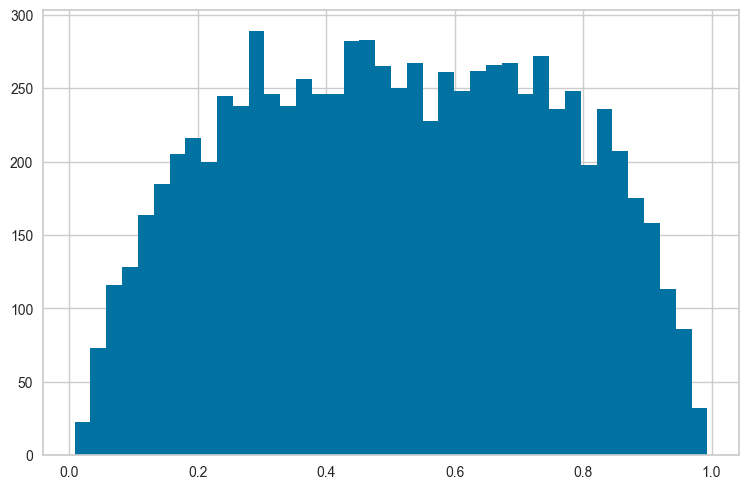

In [12]:
plt.hist(nuisance_e,bins=40)

In [13]:
print(min(nuisance_e))
print(max(nuisance_e))

0.008599996566772461
0.9934999942779541


In [14]:
np.quantile(nuisance_e,q=[0,0.05,0.1,0.2,0.8,0.9,0.95,1.0])

array([0.0086    , 0.12129998, 0.17559999, 0.26749998, 0.7482    ,
       0.838     , 0.890805  , 0.99349999])

In [15]:
nuisance_e[nuisance_e<1e-07]=1e-07
nuisance_e[nuisance_e>(1-1e-07)]=1-1e-07

metrics function

In [16]:
from sklearn.neighbors import KNeighborsRegressor

def DR_risk_score(cate_pred, y, t, y1_pred, y0_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    dr_pseudo = (t / t_pred - (1 - t) / (1 - t_pred)) * y \
                + (1 - t / t_pred) * y1_pred \
                - (1 - (1 - t) / (1 - t_pred)) * y0_pred
    score = np.mean((dr_pseudo - cate_pred)**2)
    return score

def R_risk_score(cate_pred, y, t, mu_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    y_tilde = y - mu_pred
    t_tilde = t - t_pred
    r_pseudo = y_tilde / t_tilde
    r_weight = t_tilde**2
    score = np.mean(r_weight*((r_pseudo - cate_pred)**2))
    return score

def T_risk_score(cate_pred, y, t, y1_pred, y0_pred):
    pseudo_outcome = np.zeros_like(y)
    pseudo_outcome[t == 0] = y1_pred[t == 0] - y[t == 0]
    pseudo_outcome[t == 1] = y[t == 1] - y0_pred[t == 1]
    score = np.mean((pseudo_outcome - cate_pred)**2)
    return score

def U_risk_score(cate_pred, y, t, mu_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    y_tilde = y - mu_pred
    t_tilde = t - t_pred
    U_pseudo = y_tilde / t_tilde
    score = np.mean((U_pseudo - cate_pred)**2)
    return score

def F_risk_score(cate_pred, y, t, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    f_pseudo = y * (t - t_pred) / (t_pred * (1 - t_pred))
    score = np.mean((f_pseudo - cate_pred)**2)
    return score

def KNN_score(cate_pred, y, t, X, k=1):
    nn0 = KNeighborsRegressor(n_neighbors=k, weights="distance")
    nn1 = KNeighborsRegressor(n_neighbors=k, weights="distance")
    nn0 = nn0.fit(X[t == 0], y[t == 0])
    nn1 = nn1.fit(X[t == 1], y[t == 1])

    y_cf = np.zeros_like(y)
    y_cf[t == 0] = nn1.predict(X[t == 0])
    y_cf[t == 1] = nn0.predict(X[t == 1])
    ite_nn = np.zeros_like(y)
    ite_nn[t == 0] = y_cf[t == 0] - y[t == 0]
    ite_nn[t == 1] = y[t == 1] - y_cf[t == 1]
    score = np.mean((ite_nn - cate_pred)**2)
    return score

def IF_score(cate_pred, y, t, y1_pred, y0_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    y_factual = y
    pseudo_outcomes = y1_pred - y0_pred
    d_term = t - t_pred
    c_term = t_pred * (1 - t_pred)
    b_term = 2 * t * (t - t_pred) / c_term
    objective_value = ((1 - b_term) * (pseudo_outcomes ** 2) +
                           b_term * y_factual * (pseudo_outcomes - cate_pred) -
                           d_term * (pseudo_outcomes - cate_pred) ** 2 + cate_pred ** 2)
    score = np.mean(objective_value)
    return score

In [17]:
import optuna
import optuna.trial as trial

def objective(trial, x_train=XX, t_train=treatmentX, y_train=yX, ym=np.array(ym), ys=np.array(ys),
              nuisance_e=nuisance_e, nuisance_m=nuisance_m, nuisance_m1=nuisance_m1, nuisance_m0=nuisance_m0):

    # split data to training & validation
    # split data to training & validation
    np.random.seed(61985)
    val_split = 0.3
    size = int(x_train.shape[0]*(1-val_split))
    ind = np.random.permutation(np.array(list(range(x_train.shape[0]))))
    ind_tr = ind[:size]
    ind_te = ind[size:]
    x_train_tr = x_train.iloc[ind_tr,:]
    t_train_tr = t_train.iloc[ind_tr]
    y_train_tr = y_train.iloc[ind_tr]
    x_train_te = x_train.iloc[ind_te,:]
    t_train_te = t_train.iloc[ind_te]
    y_train_te = y_train.iloc[ind_te]
    true_ite_train_te = true_ite_train[ind_te]

    e_tr = nuisance_e[ind_tr]
    e_te = nuisance_e[ind_te]
    m_te = nuisance_m[ind_te]
    m_te = m_te*ys+ym
    m1_te = nuisance_m1[ind_te]
    m1_te = m1_te*ys+ym
    m0_te = nuisance_m0[ind_te]
    m0_te = m0_te*ys+ym

    params = {
        'neurons_r_layer_w': trial.suggest_int('neurons_r_layer_w', 1, x_train.shape[1]*0.6, 1),
        "neurons_r_layer_c0": trial.suggest_int("neurons_r_layer_c0", 1, x_train.shape[1]*0.6, 1),
        'neurons_r_layer_o0': trial.suggest_int('neurons_r_layer_o0', 1, x_train.shape[1]*0.6, 1),
        'neurons_r_layer_o1': trial.suggest_int('neurons_r_layer_o1', 1, x_train.shape[1]*0.6, 1),
        'neurons_out_layer': trial.suggest_float('neurons_out_layer', 1, 4),
        'num_layers': trial.suggest_int('num_layers', 1, 4, 1),
        'alpha': trial.suggest_float('alpha', -4, 2.000001),
        'ratio': trial.suggest_float('ratio', -5, 1.000001),
        # 'ratio2': trial.suggest_float('ratio2', -5, 1),
        'reg_l2': trial.suggest_int('reg_l2', -6, -1),
        'batch_size': trial.suggest_int('batch_size', 7, 9),
        'learning_rate': trial.suggest_float('learning_rate', -6, -5),
    }
    
    #training
    def dragonnet_mu_risk(concat_true, concat_pred, alpha=round(10**params["alpha"],7)):
        return mu_risk_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)

    def seed_every(seed):
        random.seed(seed)
        np.random.seed(seed)
        tf.random.set_seed(seed)
    seed_every(805619) 
    snet_yc =  SNet_yc(loss_func = dragonnet_mu_risk, \
                      neurons_r_layer_w = params["neurons_r_layer_w"], \
                      neurons_r_layer_c0 = params["neurons_r_layer_c0"],\
                      neurons_r_layer_o0 = params["neurons_r_layer_o0"], neurons_r_layer_o1 = params["neurons_r_layer_o1"], \
                      neurons_out_layer = int(2**params["neurons_out_layer"]), num_layers = params["num_layers"], \
                      batch_size = 2**params["batch_size"], learning_rate = 10**params["learning_rate"], epochs = 5000, adam_epochs = 100, \
                      reg_disc = True, ratio = round(10**params["ratio"],4), reg_orth = True, ratio2 = 0, reg_l2 = 10**params["reg_l2"])
    
    with contextlib.redirect_stdout(io.StringIO()):
        snet_yc_ite_initial = snet_yc.fit_predict(x_train_tr, t_train_tr, y_train_tr, e_tr, return_components=False)
    
    snet_ycpred = snet_yc.predict(x_train_te)
    snet_ycpred[:,0] = snet_ycpred[:,0]*ys + ym
    snet_ycpred[:,1] = snet_ycpred[:,1]*ys + ym
    mu = np.array(snet_ycpred[:,1])*np.array(t_train_te) + np.array(snet_ycpred[:,0])*(1-np.array(t_train_te))
    MSE_Y = np.mean((np.array(y_train_te*ys + ym)-mu)**2)
    CE = log_loss(np.array(t_train_te),np.array(snet_ycpred[:,2]))

    snet_yc_ite = np.array(snet_ycpred[:,1])-np.array(snet_ycpred[:,0])
    yy = np.array(y_train_te*ys + ym)
    tt = np.array(t_train_te)
    xx = np.array(x_train_te)
    yy_tr = np.array(y_train_tr*ys + ym)
    tt_tr = np.array(t_train_tr)
    ATE_naive = np.mean(yy_tr[tt_tr==1]) - np.mean(yy_tr[tt_tr==0])
    ate = np.repeat(a=ATE_naive, repeats=len(yy))

    # DR-risk
    DR_risk1 = DR_risk_score(snet_yc_ite,yy,tt,m1_te,m0_te,e_te)
    DR_baseline = DR_risk_score(ate,yy,tt,m1_te,m0_te,e_te)
    DR_risk = DR_risk1/DR_baseline
    # R-risk
    R_risk1 = R_risk_score(snet_yc_ite,yy,tt,m_te,e_te)
    R_baseline = R_risk_score(ate,yy,tt,m_te,e_te)
    R_risk = R_risk1/R_baseline
    # T-risk
    T_risk1 = T_risk_score(snet_yc_ite,yy,tt,m1_te,m0_te)
    T_baseline = T_risk_score(ate,yy,tt,m1_te,m0_te)
    T_risk = T_risk1/T_baseline
    # U-risk
    U_risk1 = U_risk_score(snet_yc_ite,yy,tt,m_te,e_te)
    U_baseline = U_risk_score(ate,yy,tt,m_te,e_te)
    U_risk = U_risk1/U_baseline
    # F-risk
    F_risk1 = F_risk_score(snet_yc_ite,yy,tt,e_te)
    F_baseline = F_risk_score(ate,yy,tt,e_te)
    F_risk = F_risk1/F_baseline
    # KNN
    KNN_val1 = KNN_score(snet_yc_ite,yy,tt,xx)
    KNN_baseline = KNN_score(ate,yy,tt,xx)
    KNN_val = KNN_val1/KNN_baseline
    # IF
    IF_val1 = IF_score(snet_yc_ite,yy,tt,m1_te,m0_te,e_te)
    IF_baseline = IF_score(ate,yy,tt,m1_te,m0_te,e_te)
    IF_val = IF_val1/IF_baseline
    # CE
    y_hat_naive = np.repeat(a=np.mean(yy_tr), repeats=len(yy))
    MSE_Ybaseline = np.mean((yy-y_hat_naive)**2)
    MSE_Y = MSE_Y/MSE_Ybaseline
    t_hat_naive = np.repeat(a=np.mean(tt_tr), repeats=len(tt))
    CE_Tbaseline = log_loss(tt, t_hat_naive)
    CE_T = CE/CE_Tbaseline

    # mu-risk-ce
    a = (np.array(y_train_te*ys + ym) -mu)**2
    pp = e_te
    pp[pp<1e-7]=1e-7
    pp[pp>(1-1e-7)]=(1-1e-7)
    b = tt/pp+(1-tt)/(1-pp)
    mu_risk = np.mean(a*b)

    # pehe
    pehe_valid = np.sqrt(np.mean((true_ite_train_te.numpy().squeeze()-snet_yc_ite)**2))

    # print(f"pehe={pehe_valid}, mu_riskce={mu_risk}")
    # trial.set_user_attr("CE", CE)
    # trial.set_user_attr("MSE", MSE_Y)
    # trial.set_user_attr("mu_risk", mu_risk)
    # trial.set_user_attr("IF", IF_val)
    
    # return DR_risk, R_risk, T_risk, U_risk, F_risk, KNN_val, MSE_Y, CE_T


    print(f"pehe={pehe_valid}, DR_risk={DR_risk}, R_risk={R_risk}, mu_risk={mu_risk}, CE_T={CE}")
    trial.set_user_attr("DR_risk", DR_risk)
    trial.set_user_attr("R_risk", R_risk)
    trial.set_user_attr("T_risk", T_risk)
    trial.set_user_attr("U_risk", U_risk)
    trial.set_user_attr("F_risk", F_risk)
    trial.set_user_attr("KNN_val", KNN_val)
    trial.set_user_attr("IF", IF_val)
    trial.set_user_attr("CE", CE_T)
    trial.set_user_attr("MSE", MSE_Y)
    trial.set_user_attr("IF", IF_val)
    
    return mu_risk + CE

In [18]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sampler = optuna.samplers.TPESampler(seed=85619)
    study = optuna.create_study(direction="minimize",sampler=sampler)
    study.optimize(objective, n_trials = 130)

[I 2026-08-13 00:52:30,094] A new study created in memory with name: no-name-9cd14429-c911-4d82-ac2f-1dd8e88d4fda



79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step


[I 2026-08-13 00:53:01,715] Trial 0 finished with value: 2.462181733138369 and parameters: {'neurons_r_layer_w': 12, 'neurons_r_layer_c0': 3, 'neurons_r_layer_o0': 2, 'neurons_r_layer_o1': 10, 'neurons_out_layer': 2.6246412382605886, 'num_layers': 2, 'alpha': -2.0290011277091002, 'ratio': -0.292217011975616, 'reg_l2': -5, 'batch_size': 7, 'learning_rate': -5.60578273552371}. Best is trial 0 with value: 2.462181733138369.


pehe=1.0114325284957886, DR_risk=0.9426556125148144, R_risk=1.2484299415368298, mu_risk=1.8770578679216214, CE_T=0.5851238652167474
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step


[I 2026-08-13 00:53:29,334] Trial 1 finished with value: 2.4416453212577203 and parameters: {'neurons_r_layer_w': 3, 'neurons_r_layer_c0': 2, 'neurons_r_layer_o0': 11, 'neurons_r_layer_o1': 6, 'neurons_out_layer': 2.643423990372876, 'num_layers': 2, 'alpha': -0.76714699731308, 'ratio': -1.496544403948338, 'reg_l2': -5, 'batch_size': 8, 'learning_rate': -5.055562469650767}. Best is trial 1 with value: 2.4416453212577203.


...

pehe=0.48843979835510254, DR_risk=0.577994170805964, R_risk=0.7496347353280552, mu_risk=0.571462604009122, CE_T=0.5795341507925893
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[I 2026-08-14 01:49:11,120] Trial 128 finished with value: 1.1830242765357046 and parameters: {'neurons_r_layer_w': 12, 'neurons_r_layer_c0': 10, 'neurons_r_layer_o0': 4, 'neurons_r_layer_o1': 2, 'neurons_out_layer': 3.7750831719323115, 'num_layers': 2, 'alpha': -2.553518044601819, 'ratio': 0.5420506940366407, 'reg_l2': -1, 'batch_size': 8, 'learning_rate': -5.786363482986736}. Best is trial 96 with value: 0.938536870899721.


pehe=0.6157881021499634, DR_risk=0.6530444758397999, R_risk=0.8054039978080966, mu_risk=0.5962583970282852, CE_T=0.5867658795074194
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[I 2026-08-14 01:50:41,241] Trial 129 finished with value: 2.5034337597768825 and parameters: {'neurons_r_layer_w': 14, 'neurons_r_layer_c0': 14, 'neurons_r_layer_o0': 2, 'neurons_r_layer_o1': 1, 'neurons_out_layer': 3.6981626027443197, 'num_layers': 2, 'alpha': -3.441938928232016, 'ratio': -0.7429149340449039, 'reg_l2': -1, 'batch_size': 8, 'learning_rate': -5.925399355504873}. Best is trial 96 with value: 0.938536870899721.


pehe=1.0360745191574097, DR_risk=0.9415279379204621, R_risk=1.2451421179797852, mu_risk=1.9280990811398397, CE_T=0.5753346786370428


In [19]:
plotly_config = {"staticPlot": True}
fig = plot_optimization_history(study)
fig.show(config=plotly_config)

In [20]:
study.best_trial.params

{'neurons_r_layer_w': 7,
 'neurons_r_layer_c0': 8,
 'neurons_r_layer_o0': 4,
 'neurons_r_layer_o1': 2,
 'neurons_out_layer': 3.4986044054796968,
 'num_layers': 2,
 'alpha': -3.483646933577887,
 'ratio': 0.5547217734747123,
 'reg_l2': -2,
 'batch_size': 8,
 'learning_rate': -5.833091686894272}

------------------------------------------------------------------------------

In [21]:
args = {
    'model_name':"SNet_yc",
    'neurons_r_layer_w': study.best_trial.params['neurons_r_layer_w'],
    'neurons_r_layer_c0': study.best_trial.params['neurons_r_layer_c0'],
    'neurons_r_layer_o0': study.best_trial.params['neurons_r_layer_o0'],
    'neurons_r_layer_o1': study.best_trial.params['neurons_r_layer_o1'],
    'neurons_out_layer': int(2**study.best_trial.params['neurons_out_layer']),
    'num_layers': study.best_trial.params['num_layers'],
    'alpha':round(10**study.best_trial.params['alpha'],7),
    'ratio':round(10**study.best_trial.params['ratio'],4),
    # 'ratio2':round(10**study.best_trial.params['ratio2'],4), 
    'batch_size':2**study.best_trial.params["batch_size"],
    'learning_rate':10**study.best_trial.params["learning_rate"],
    'reg_l2':10**study.best_trial.params["reg_l2"]
}
args

{'model_name': 'SNet_yc',
 'neurons_r_layer_w': 7,
 'neurons_r_layer_c0': 8,
 'neurons_r_layer_o0': 4,
 'neurons_r_layer_o1': 2,
 'neurons_out_layer': 11,
 'num_layers': 2,
 'alpha': 0.0003284,
 'ratio': 3.5869,
 'batch_size': 256,
 'learning_rate': 1.4686161952500608e-06,
 'reg_l2': 0.01}

In [18]:
args = {
    'model_name':"SNet_yc",
    'neurons_r_layer_w': 7,
    'neurons_r_layer_c0': 8,
    'neurons_r_layer_o0': 4,
    'neurons_r_layer_o1': 2,
    'neurons_out_layer': 11,
    'num_layers': 2,
    'alpha': 0.0003284,
    'ratio': 3.5869,
    'ratio2': 0.0, 
    'batch_size': 256,
    'learning_rate': 1.4686161952500608e-06,
    'reg_l2': 0.01
}
args

{'model_name': 'SNet_yc',
 'neurons_r_layer_w': 7,
 'neurons_r_layer_c0': 8,
 'neurons_r_layer_o0': 4,
 'neurons_r_layer_o1': 2,
 'neurons_out_layer': 11,
 'num_layers': 2,
 'alpha': 0.0003284,
 'ratio': 3.5869,
 'ratio2': 0.0,
 'batch_size': 256,
 'learning_rate': 1.4686161952500608e-06,
 'reg_l2': 0.01}

In [19]:
# args = {
#     'model_name':"SNet_yc",
#     'neurons_r_layer_w': 10,
#     'neurons_r_layer_c0': 9,
#     'neurons_r_layer_o0': 4,
#     'neurons_r_layer_o1': 9,
#     'neurons_out_layer': 9,
#     'num_layers': 2,
#     'alpha': 0.0020538*2,
#     'ratio': 0.0157448*2,
#     'ratio2': 0.0, 
#     'batch_size': 256,
#     'learning_rate': 6.3504400945871795e-06,
#     'reg_l2': 1e-06*2
# }
# args

In [20]:
yss = ys
ymm = ym
ys = np.array(yss)
ym = np.array(ymm)
def dragonnet_mu_risk(concat_true, concat_pred, alpha=args['alpha']):
    return mu_risk_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)
def dragonnet_loss_binarycross(concat_true, concat_pred, alpha=args['alpha']):
    return regression_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)

def seed_every(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
seed_every(805619)
# seed_every(856019)
snet_yc =  SNet_yc(loss_func=dragonnet_mu_risk,\
                   neurons_r_layer_w = args["neurons_r_layer_w"], \
                   neurons_r_layer_c0 = args["neurons_r_layer_c0"],\
                   neurons_r_layer_o0 = args["neurons_r_layer_o0"], neurons_r_layer_o1 = args["neurons_r_layer_o1"], \
                   neurons_out_layer = args["neurons_out_layer"], num_layers = args["num_layers"],\
                   batch_size = args["batch_size"], learning_rate = args["learning_rate"], epochs = 5000, adam_epochs = 100, \
                   reg_disc = True, ratio = args["ratio"], reg_orth = True, ratio2 = args["ratio2"], reg_l2 = args["reg_l2"])

snet_yc_ite_initial = snet_yc.fit_predict(XX, treatmentX, yX, nuisance_e, return_components=False)
snet_yc_ite_initial=snet_yc_ite_initial*ys
snet_yc_ate_initial = snet_yc_ite_initial.mean()
snet_ycpred=snet_yc.predict(X, treatment, y)
snet_ycpred[:,0]=snet_ycpred[:,0]*ys+ym
snet_ycpred[:,1]=snet_ycpred[:,1]*ys+ym

df_preds_initial = pd.DataFrame([snet_ycpred[:,1]-snet_ycpred[:,0],
                                 treatment.ravel(),
                                 y.ravel()],
                                 index=['snet_yc','w','y']).T


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - binary_classification_loss: 177.3505 - loss: 501.9738 - mu_risk_loss: 501.4093 - track_epsilon: 0.1026 - treatment_accuracy: 0.5117 - val_binary_classification_loss: 174.0338 - val_loss: 493.2785 - val_mu_risk_loss: 491.7301 - val_track_epsilon: 0.1026 - val_treatment_accuracy: 0.6060 - learning_rate: 0.0010
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_classification_loss: 176.1715 - loss: 456.2470 - mu_risk_loss: 454.7685 - track_epsilon: 0.1026 - treatment_accuracy: 0.6364 - val_binary_classification_loss: 170.1430 - val_loss: 430.0789 - val_mu_risk_loss: 424.3608 - val_track_epsilon: 0.1026 - val_treatment_accuracy: 0.6885 - learning_rate: 0.0010
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_classification_loss: 169.8045 - loss: 400.0130 - mu_risk_loss: 392.7688 - track_epsilon: 0.1026 - treatment_accuracy: 0.6946 - val_binary_classification_loss: 156.6239 - val_loss: 400.7650 - val_mu_risk_loss: 395

In [21]:
layers=snet_yc.dragonnet.layers
layers_names=[]
for i in range(len(layers)):
    a_layer=snet_yc.dragonnet.layers[i]
    layers_names=layers_names+[a_layer.name]
layers_names=np.array(layers_names)
layers_names_idx=list(range(len(layers)))
layers_names_idx=np.array(layers_names_idx)
layers_names

array(['input', 'input_confounder0', 'input_adjustment0',
       'input_adjustment1', 'x_c0_1', 'x_o0_1', 'x_o1_1',
       'input_instrument', 'x_c0_2', 'x_o0_2', 'x_o1_2', 'x_w_1',
       'concatenate_1', 'concatenate_2', 'x_w_2', 'y0_hidden_1',
       'y1_hidden_1', 'concatenate', 'y0_hidden_2', 'y1_hidden_2',
       't_predictions', 'y0_predictions', 'y1_predictions',
       'epsilon_layer', 'concatenate_3'], dtype='<U17')

In [22]:
layer_w0=snet_yc.dragonnet.layers[layers_names_idx[layers_names=="input_instrument"][0]]
weights_w0,bias_w0 = layer_w0.weights
layer_c00=snet_yc.dragonnet.layers[layers_names_idx[layers_names=="input_confounder0"][0]]
weights_c00,bias_c00 = layer_c00.weights
# layer_c01=snet_yc.dragonnet.layers[layers_names_idx[layers_names=="input_confounder1"][0]]
# weights_c01,bias_c01 = layer_c01.weights
layer_o00=snet_yc.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment0"][0]]
weights_o00,bias_o00 = layer_o00.weights
layer_o01=snet_yc.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment1"][0]]
weights_o01,bias_o01 = layer_o01.weights

In [23]:
instrument_wts=tf.reduce_sum(tf.abs(weights_w0),axis=1)
instrument_wts=instrument_wts/tf.sqrt(tf.reduce_sum(instrument_wts**2))
confounder_wts0=tf.reduce_sum(tf.abs(weights_c00),axis=1)
confounder_wts0=confounder_wts0/tf.sqrt(tf.reduce_sum(confounder_wts0**2))
# confounder_wts1=tf.reduce_sum(tf.abs(weights_c01),axis=1)
# confounder_wts1=confounder_wts1/tf.sqrt(tf.reduce_sum(confounder_wts1**2))
adjustment_wts0=tf.reduce_sum(tf.abs(weights_o00),axis=1)
adjustment_wts0=adjustment_wts0/tf.sqrt(tf.reduce_sum(adjustment_wts0**2))
adjustment_wts1=tf.reduce_sum(tf.abs(weights_o01),axis=1)
adjustment_wts1=adjustment_wts1/tf.sqrt(tf.reduce_sum(adjustment_wts1**2))

print("instrument block vs covariates")
print(instrument_wts)
print()
print("confounder0 block vs covariates")
print(confounder_wts0)
print()
# print("confounder1 block vs covariates")
# print(confounder_wts1)
# print()
print("adjustment0 block vs covariates")
print(adjustment_wts0)
print()
print("adjustment1 block vs covariates")
print(adjustment_wts1)
print()
aa = tf.reduce_sum(instrument_wts*confounder_wts0)
# bb = tf.reduce_sum(instrument_wts*confounder_wts1)
cc = tf.reduce_sum(instrument_wts*adjustment_wts0)
dd = tf.reduce_sum(instrument_wts*adjustment_wts1)
# ee = tf.reduce_sum(confounder_wts0*confounder_wts1)
ff = tf.reduce_sum(confounder_wts0*adjustment_wts0)
gg = tf.reduce_sum(confounder_wts0*adjustment_wts1)
# hh = tf.reduce_sum(confounder_wts1*adjustment_wts0)
# ii = tf.reduce_sum(confounder_wts1*adjustment_wts1)
jj = tf.reduce_sum(adjustment_wts0*adjustment_wts1)
print(f"zt vs zc0: {aa}")
# print(f"zt vs zc1: {bb}")
print(f"zt vs zy0: {cc}")
print(f"zt vs zy1: {dd}")
# print(f"zc0 vs zc1: {ee}")
print(f"zc0 vs zy0: {ff}")
print(f"zc0 vs zy1: {gg}")
# print(f"zc1 vs zy0: {hh}")
# print(f"zc1 vs zy1: {ii}")
print(f"zy0 vs zy1: {jj}")
# print(f"total: {aa+bb+cc+dd+ee+ff+gg+hh+ii+jj}")
print(f"total: {aa+cc+dd+ff+gg+jj}")

instrument block vs covariates
tf.Tensor(
[0.20654473 0.20848998 0.25541908 0.25217852 0.22874251 0.20802629
 0.19456273 0.21330333 0.2072163  0.19310075 0.1465684  0.18137376
 0.16998452 0.17648181 0.2043304  0.27556008 0.16597982 0.15994333
 0.14775689 0.26600426 0.11417466 0.1669817  0.21178435 0.22245304
 0.11304357], shape=(25,), dtype=float32)

confounder0 block vs covariates
tf.Tensor(
[0.02406523 0.02471806 0.32788742 0.10233267 0.42326635 0.38463053
 0.3640379  0.41131836 0.38758355 0.07681639 0.10032412 0.1583791
 0.11055735 0.17081545 0.09988549 0.02633041 0.02652023 0.02746443
 0.03948764 0.02281371 0.03937033 0.02033681 0.02834932 0.02411572
 0.04240577], shape=(25,), dtype=float32)

adjustment0 block vs covariates
tf.Tensor(
[0.0431052  0.05778014 0.06573337 0.27045518 0.10377881 0.3075238
 0.07774817 0.1326274  0.28834823 0.41188923 0.46312863 0.29419735
 0.27093977 0.18527606 0.30661625 0.05489325 0.04269243 0.06504994
 0.08237674 0.03905822 0.04636402 0.02450058 0.0378

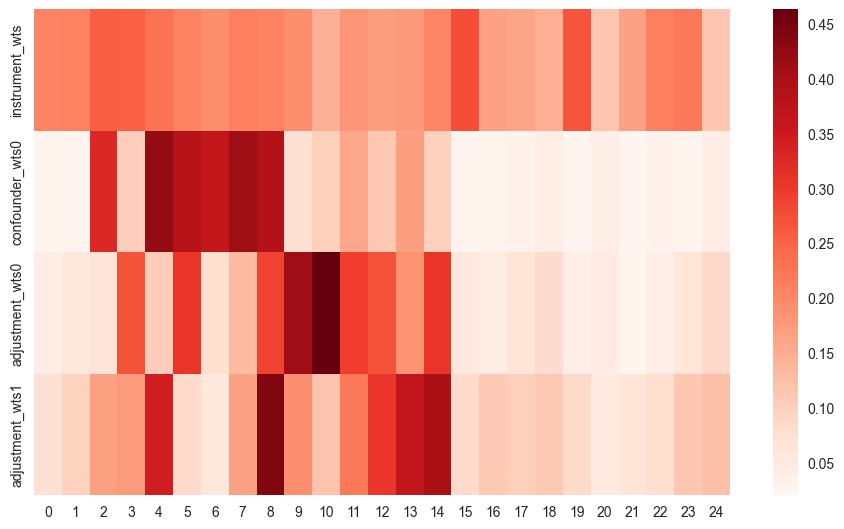

In [24]:
import seaborn as sns
all_latent_wts={"instrument_wts":np.array(instrument_wts),
                "confounder_wts0":np.array(confounder_wts0),
                # "confounder_wts1":np.array(confounder_wts1),
                "adjustment_wts0":np.array(adjustment_wts0),
                "adjustment_wts1":np.array(adjustment_wts1)}
all_latent_wts=pd.DataFrame(all_latent_wts).T
plt.rcParams['figure.figsize'] = 10.0, 6.0
sns.heatmap(all_latent_wts,annot_kws={"size":10},cmap="Reds")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

(array([ 94., 181., 267., 318., 325., 320., 366., 348., 320., 369., 338.,
        293., 312., 343., 298., 327., 342., 319., 295., 338., 340., 332.,
        298., 329., 298., 328., 326., 371., 337., 344., 322., 348., 338.,
        320., 330., 289., 262., 199., 135.,  41.]),
 array([0.0037276 , 0.02843395, 0.05314029, 0.07784664, 0.10255299,
        0.12725934, 0.15196569, 0.17667203, 0.20137838, 0.22608472,
        0.25079107, 0.27549744, 0.30020377, 0.3249101 , 0.34961647,
        0.3743228 , 0.39902917, 0.4237355 , 0.44844186, 0.4731482 ,
        0.49785456, 0.52256089, 0.54726726, 0.57197362, 0.59667993,
        0.62138629, 0.64609265, 0.67079896, 0.69550532, 0.72021168,
        0.74491805, 0.76962435, 0.79433072, 0.81903708, 0.84374344,
        0.86844975, 0.89315611, 0.91786247, 0.94256884, 0.96727514,
        0.99198151]),
 <BarContainer object of 40 artists>)

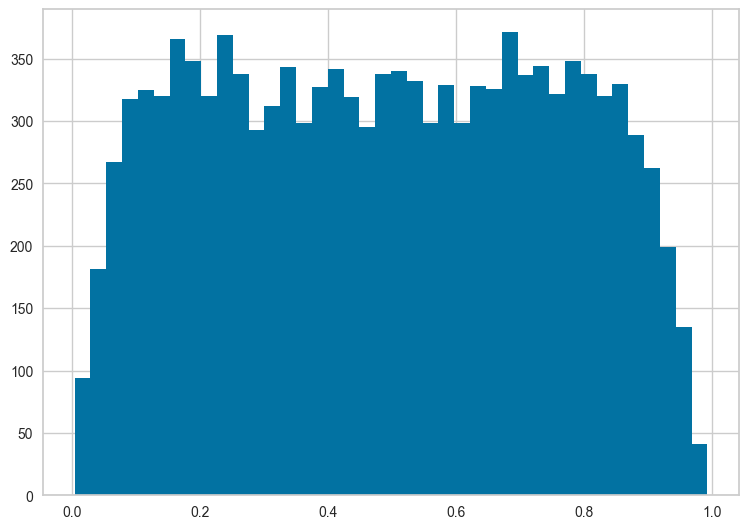

In [25]:
plt.rcParams['figure.figsize'] = 8.0, 6.0
plt.hist(snet_ycpred[:,2],bins=40)

        snet_yc    w         y
0     -0.919153  0.0  0.421445
1      1.221600  0.0 -0.024604
2     -0.082885  0.0  1.485467
3     -0.916187  1.0 -0.458699
4      1.349721  1.0  1.114336
...         ...  ...       ...
11995  1.071097  0.0 -1.350952
11996  1.312521  0.0 -0.046919
11997  1.053793  0.0  0.566376
11998  1.872434  0.0  0.685549
11999  0.433338  1.0  1.299354

[12000 rows x 3 columns]


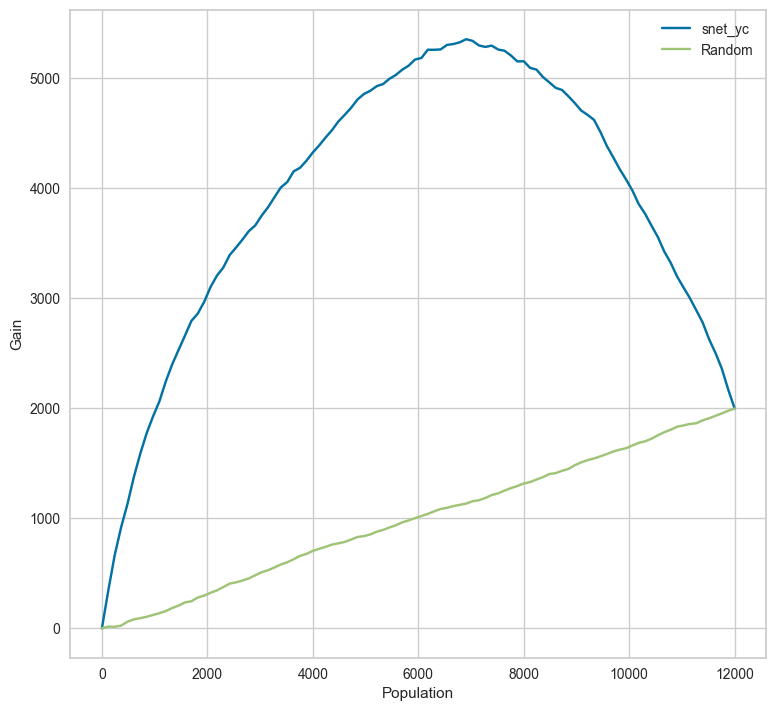

In [26]:
print(df_preds_initial)
plt.rcParams['figure.figsize'] = 10.0, 7.5
plot_gain(df_preds_initial)
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------

ITE estimate

In [27]:
snet_yc_pred=snet_yc.predict(Xt)
snet_yc_pred[:,0]=snet_yc_pred[:,0]*ys+ym
snet_yc_pred[:,1]=snet_yc_pred[:,1]*ys+ym
snet_yc_pred_tr=snet_yc.predict(XX)
snet_yc_pred_tr[:,0]=snet_yc_pred_tr[:,0]*ys+ym
snet_yc_pred_tr[:,1]=snet_yc_pred_tr[:,1]*ys+ym
snet_yc_pred_all=snet_yc.predict(X)
snet_yc_pred_all[:,0]=snet_yc_pred_all[:,0]*ys+ym
snet_yc_pred_all[:,1]=snet_yc_pred_all[:,1]*ys+ym

snet_yc_ite = np.array(snet_yc_pred[:,1]-snet_yc_pred[:,0])
snet_yc_ite_tr = np.array(snet_yc_pred_tr[:,1]-snet_yc_pred_tr[:,0])
snet_yc_ite_all = np.array(snet_yc_pred_all[:,1]-snet_yc_pred_all[:,0])

snet_yc_t = np.array(snet_yc_pred[:,2])
snet_yc_t_tr = np.array(snet_yc_pred_tr[:,2])
snet_yc_t_all = np.array(snet_yc_pred_all[:,2])

snet_yc_y1 = np.array(snet_yc_pred[:,1])
snet_yc_y1_tr = np.array(snet_yc_pred_tr[:,1])
snet_yc_y1_all = np.array(snet_yc_pred_all[:,1])

snet_yc_y0 = np.array(snet_yc_pred[:,0])
snet_yc_y0_tr = np.array(snet_yc_pred_tr[:,0])
snet_yc_y0_all = np.array(snet_yc_pred_all[:,0])

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [28]:
# plt.figure(figsize=(8, 6))
# plt.scatter(y_test[t_test==1].numpy().squeeze()*ys+ym,snet_yc_y1[t_test==1])
# plt.plot([-4,4],[-4,4],color="red",linestyle="--",linewidth=1)

(-3.5, 6.5)

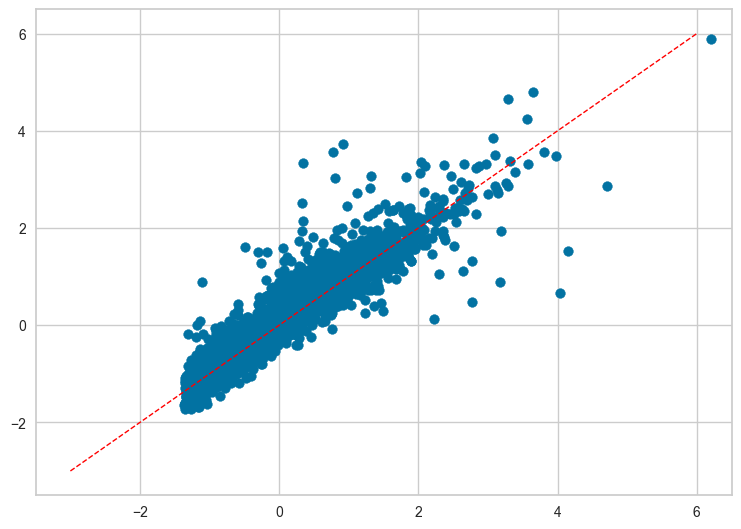

In [29]:
plt.figure(figsize=(8, 6))
plt.scatter(true_ite_test.numpy().squeeze(),snet_yc_ite)
plt.plot([-3,6],[-3,6],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,6.5)
plt.ylim(-3.5,6.5)

(-3.5, 6.5)

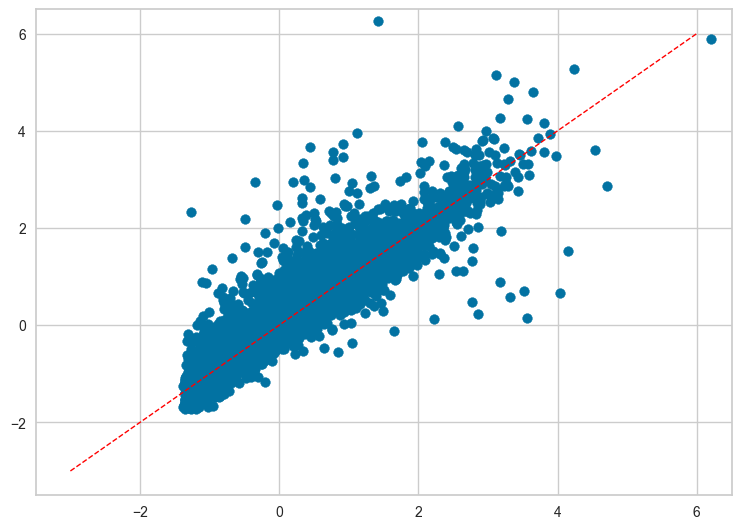

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(true_ite.numpy().squeeze(),snet_yc_ite_all)
plt.plot([-3,6],[-3,6],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,6.5)
plt.ylim(-3.5,6.5)

In [45]:
#murisk_ce loss
pehe_train = np.sqrt(np.mean((true_ite_train.numpy().squeeze()-snet_yc_ite_tr)**2))
pehe_test = np.sqrt(np.mean((true_ite_test.numpy().squeeze()-snet_yc_ite)**2))
pehe_all = np.sqrt(np.mean((true_ite.numpy().squeeze()-snet_yc_ite_all)**2))
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite.mean()}")
print(f"pred ATE:  {snet_yc_ite_all.mean()}")
print(abs(true_ite.mean()-snet_yc_ite_all.mean()))

Train:  0.3351546823978424
Test:  0.33373746275901794
ALL data:  0.3347301781177521
True ATE:  0.1443278193473816
pred ATE:  0.22855466604232788
tensor(0.0842)


In [31]:
#original loss
pehe_train = np.sqrt(np.mean((true_ite_train.numpy().squeeze()-snet_yc_ite_tr)**2))
pehe_test = np.sqrt(np.mean((true_ite_test.numpy().squeeze()-snet_yc_ite)**2))
pehe_all = np.sqrt(np.mean((true_ite.numpy().squeeze()-snet_yc_ite_all)**2))
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite.mean()}")
print(f"pred ATE:  {snet_yc_ite_all.mean()}")
print(abs(true_ite.mean()-snet_yc_ite_all.mean()))

Train:  0.3351546823978424
Test:  0.33373746275901794
ALL data:  0.3347301781177521
True ATE:  0.1443278193473816
pred ATE:  0.22855466604232788
tensor(0.0842)


In [32]:
from sklearn.metrics import accuracy_score
a=snet_yc_t_all.copy()
a[(snet_yc_t_all>0.5)]=1
a[(snet_yc_t_all<=0.5)]=0
a_tr=snet_yc_t_tr.copy()
a_tr[(snet_yc_t_tr>0.5)]=1
a_tr[(snet_yc_t_tr<=0.5)]=0
a_ts=snet_yc_t.copy()
a_ts[(snet_yc_t>0.5)]=1
a_ts[(snet_yc_t<=0.5)]=0
aa = df["Treat"]
print(f"accuracy_Train:  {accuracy_score(np.array(treatmentX),a_tr)}")
print(f"accuracy_Test:  {accuracy_score(np.array(treatmentt),a_ts)}")
print(f"accuracy_all:  {accuracy_score(np.array(aa),a)}")
print(f"CE_Train:  {log_loss(np.array(treatmentX),snet_yc_t_tr)}")
print(f"CE_Test:  {log_loss(np.array(treatmentt),snet_yc_t)}")
print(f"CE_all:  {log_loss(np.array(aa),snet_yc_t_all)}")

accuracy_Train:  0.704047619047619
accuracy_Test:  0.7027777777777777
accuracy_all:  0.7036666666666667
CE_Train:  0.5586371112693065
CE_Test:  0.5690246026397958
CE_all:  0.5617533584297192


In [33]:
b=snet_yc_y1_all*np.array(df["Treat"])+snet_yc_y0_all*(1-np.array(df["Treat"]))
b_tr=snet_yc_y1_tr*np.array(treatmentX)+snet_yc_y0_tr*(1-np.array(treatmentX))
b_ts=snet_yc_y1*np.array(treatmentt)+snet_yc_y0*(1-np.array(treatmentt))
np.sqrt(np.mean((np.array(df["outcome"])-b)**2))
bb = df["outcome"]

print(f"mse_Train:  {np.sqrt(np.mean((np.array(y_train*yss+ymm)-b_tr)**2))}")
print(f"mse_Test:  {np.sqrt(np.mean((np.array(y_test*yss+ymm)-b_ts)**2))}")
print(f"mse_all:  {np.sqrt(np.mean((np.array(bb)-b)**2))}")

mse_Train:  0.2618896961212158
mse_Test:  0.31864407658576965
mse_all:  0.28012597838177344


In [34]:
tt=treatment
snet_yc_t_all=snet_yc_t_all
yy0=snet_yc_y0_all
yy1=snet_yc_y1_all
yy_hat=yy1*tt+yy0*(1-tt)
yy=np.array(y)*ys+ym
term1=snet_yc_ite_all
term2=tt/snet_yc_t_all-(1-tt)/(1-snet_yc_t_all)
term3=yy-yy_hat
DR_pseudo = term1+term2*term3

R_m=yy1*snet_yc_t_all+yy0*(1-snet_yc_t_all)
R_e=snet_yc_t_all
R_Yresid=yy-R_m
R_Dresid=tt-R_e
R_pseudo=R_Yresid/R_Dresid
R_weights=R_Dresid**2

resultdata={"drcfr_ite":snet_yc_ite_all,
            "pseudo outcome_DR":DR_pseudo,
            "pseudo outcome_R":R_pseudo,
            "pseudo outcome_R_w":R_weights,
            "propensity_hat":snet_yc_t_all}
resultdata=pd.DataFrame(resultdata)
output=pd.concat([df.reset_index(drop=True),resultdata],axis=1)
# output.to_csv("snet_yc_to_metalearner_output.csv")
output

,outcome,ite,Treat,X1,X2,X3,X4,X5,X6,X7,...,X21,X22,X23,X24,X25,drcfr_ite,pseudo outcome_DR,pseudo outcome_R,pseudo outcome_R_w,propensity_hat
0,0.608289,-0.968503,0,-0.638286,0.778571,-0.025439,-0.227035,0.762376,-0.433686,-0.081588,...,0.815101,-0.734019,-0.203708,2.163823,1.231969,-0.919153,-1.427272,-1.423875,0.251680,0.501677
1,0.027236,0.671752,0,-1.129391,0.011928,1.222136,-2.386352,-0.777801,1.017212,-0.418488,...,-0.144285,0.003932,1.696536,1.903938,2.464826,1.221600,1.294364,1.587623,0.027499,0.165829
2,1.994356,-0.505744,0,1.529113,-0.324047,-0.164718,-0.290616,-1.484816,-1.179039,-1.703169,...,-1.149429,0.127326,-1.383979,-1.127948,-0.085823,-0.082885,-0.145464,-0.660703,0.009549,0.097720
3,-0.538247,-0.932438,1,-0.423696,-0.299019,-0.614782,-0.162784,0.094470,-0.720391,0.304090,...,1.963394,-1.005725,0.177842,0.833812,-0.603791,-0.916187,-1.023670,-1.084066,0.152360,0.609667
4,1.510896,0.981423,1,-0.537745,-1.059055,0.011904,-0.046251,-1.225533,1.551356,-0.758501,...,0.638206,-1.216172,-0.385572,0.805907,-0.022671,1.349721,1.050878,1.168922,0.388196,0.376946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-1.700556,0.482398,0,-1.241969,0.178361,1.169268,-2.945159,-0.423169,-1.256573,-0.209459,...,0.232130,0.012023,-1.347357,0.623794,-0.905570,1.071097,1.954750,15.855423,0.003181,0.056399
11996,-0.001834,1.058053,0,-1.416058,0.152676,0.213462,-1.673514,-0.590570,-1.985411,1.113491,...,-0.062651,0.339632,-0.368498,0.270720,1.669065,1.312521,1.124910,-0.573829,0.008183,0.090460
11997,0.797086,0.882100,0,-0.191864,1.249449,-1.971868,0.697577,-0.533814,0.284072,0.316626,...,0.403530,-0.754097,-0.577671,0.850303,0.087690,1.053793,0.746476,0.540267,0.140169,0.374392
11998,0.952328,1.596319,0,0.060644,0.709974,-0.534099,-1.344388,-1.358094,0.458564,0.073742,...,-0.795406,0.467583,-0.265747,1.780124,1.307995,1.872434,1.842962,1.816492,0.119060,0.345051


--------------------------------------------------------------------------------------------------------------------------------------------------------

In [35]:
x_name = df_test.columns
x_name = x_name.drop(["outcome","ite","Treat"])
datax = pd.DataFrame(x_test)
datax.columns = x_name

from pycaret.classification import *
model_e = load_model("15000data_nuisance_e")
nuisance_e = predict_model(model_e, data=datax)
nuisance_e["prediction_score"] = nuisance_e["prediction_score"]*nuisance_e["prediction_label"]+(1-nuisance_e["prediction_score"])*(1-nuisance_e["prediction_label"])
nuisance_e = np.array(nuisance_e["prediction_score"])

from pycaret.regression import *
model_m = load_model("15000data_nuisance_m")
nuisance_m = predict_model(model_m, data=datax)
nuisance_m = np.array(nuisance_m["prediction_label"])

from pycaret.regression import *
model_m1 = load_model("15000data_nuisance_m1")
nuisance_m1 = predict_model(model_m1, data=datax)
nuisance_m1 = np.array(nuisance_m1["prediction_label"])

from pycaret.regression import *
model_m0 = load_model("15000data_nuisance_m0")
nuisance_m0 = predict_model(model_m0, data=datax)
nuisance_m0 = np.array(nuisance_m0["prediction_label"])

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


(-3.5, 8.0)

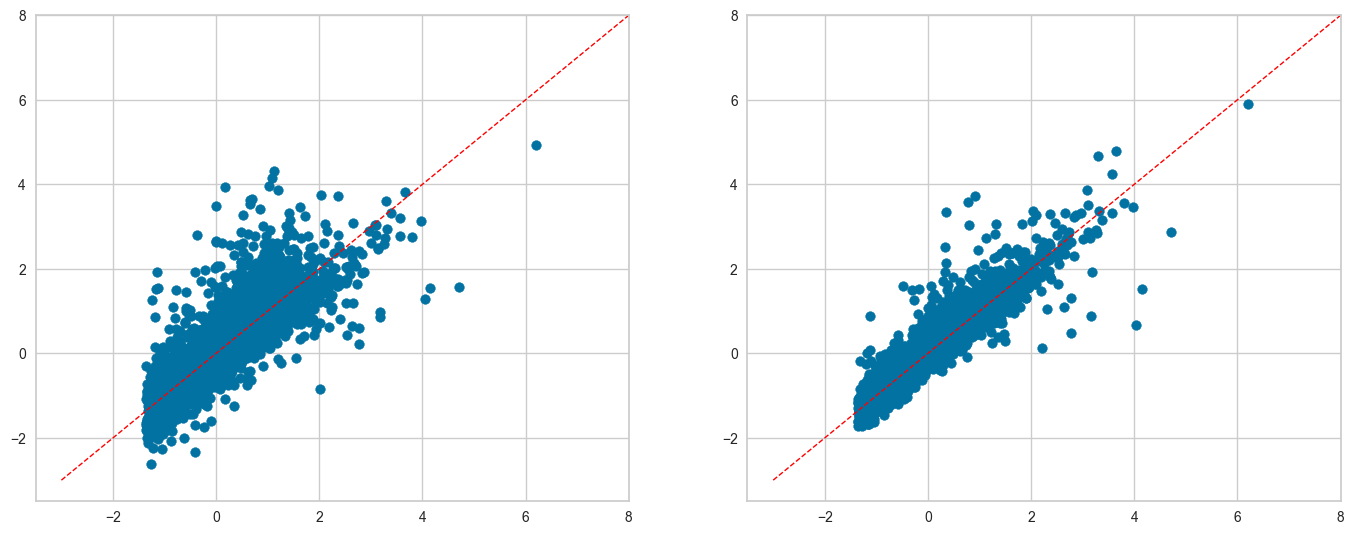

In [36]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.scatter(true_ite_test.numpy().squeeze(),(nuisance_m1-nuisance_m0)*np.array(ys))
plt.plot([-3,8],[-3,8],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,8)
plt.ylim(-3.5,8)
plt.subplot(1,2,2)
plt.scatter(true_ite_test.numpy().squeeze(),snet_yc_ite)
plt.plot([-3,8],[-3,8],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,8)
plt.ylim(-3.5,8)

In [37]:
print("nuisance pehe")
print(np.sqrt(np.mean((true_ite_test.numpy().squeeze()-(nuisance_m1-nuisance_m0)*np.array(ys))**2)))
print("SNet_yc pehe")
print(np.sqrt(np.mean((true_ite_test.numpy().squeeze()-snet_yc_ite)**2)))

nuisance pehe
0.564957967642977
SNet_yc pehe
0.33373746


In [38]:
print("ATE")
print("nuisance pehe")
print(np.abs(np.mean((true_ite_test.numpy().squeeze()-(nuisance_m1-nuisance_m0)*np.array(ys)))))
print("SNet_yc pehe")
print(np.abs(np.mean((true_ite_test.numpy().squeeze()-snet_yc_ite))))

ATE
nuisance pehe
0.08225325043586136
SNet_yc pehe
0.0785263
